In [1]:
%load_ext autoreload
%autoreload 2
import util
import pandas as pd
import logging
import numpy as np
import matplotlib.pyplot as plt
import plotting as plotting
import experiment_1

figures_path = "../figures/ION2024/"
cache_path = "cache/"

logging.basicConfig(level=logging.INFO)
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Hyperparameter Search

In [130]:
config = {
    "date": "2022-09-01T00:00:00",
    "duration_factor": 0.40,
    "solver_seed": 0,
    "RB": {},
    "FS": {
        "d": [1, 2, 3, 4],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "N_max": [2, 5, 10],
        "d_min": [0.5, 1, 2, 5],
    },
    "MCTS": {
        "d": [1, 2, 3, 4],
        "gamma": [0.8, 0.9, 0.99, 1.0],
        "d_min": [0.5, 1, 2, 5],
        "N_max": [5, 10],
        #
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
    },
    "IP": {
        "time_step_factor": [10],
    },
}
results_all = experiment_1.solve_problem(config, n_jobs=1)

FS:   0%|          | 0/1 [00:00<?, ?it/s]

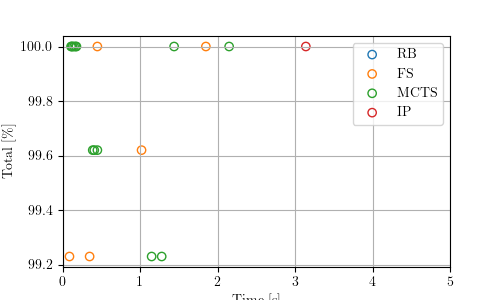

In [ ]:
plt.figure(figsize=(5, 3))
for i, solver in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[solver]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(
        time,
        total,
        label=solver,
        marker="o",
        facecolor="None",
        edgecolor=util.TABLEAU_COLORS[i],
    )
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
plt.xlim([0, 5])
plt.grid()
plt.legend()
plt.show()

In [5]:
import plotly.express as px
import pandas as pd

for solver in ["FS", "MCTS", "IP"]:
    df_dict = []
    for r in results_all[solver]:
        tmp = r["params"].copy()
        tmp["total"] = r["total"]
        tmp["time"] = r["time"]
        df_dict.append(tmp)
    df = pd.DataFrame(df_dict)

    fig = px.parallel_coordinates(df, color="total")
    fig.show()

    # Correlation of parameters to total
    correlation = df.corr()
    print(f"\n********** {solver} **********")
    print("\nHyperparameters correlation")
    print(correlation["total"].sort_values())

    # Best parameters
    print("\nBest parameters")
    print(df[df["total"] == df["total"].max()])


********** FS **********

Hyperparameters correlation
N_max   -0.230202
gamma   -0.146384
d_min    0.053344
time     0.170882
d        0.453614
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  N_max  d_min  total  time
0  3   0.99      5    0.5  100.0  0.45
1  3   0.90     10    1.0  100.0  1.85



********** MCTS **********

Hyperparameters correlation
N_max   -0.268849
n       -0.204535
gamma   -0.202371
time     0.015939
c        0.023715
d_min    0.127930
d        0.252400
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  d_min  N_max   n     c  total  time
0  3    0.8    1.0     10   5   1.0  100.0  0.11
1  3    0.8    1.0     10   5   0.1  100.0  0.12
2  3    0.8    1.0     10   5  10.0  100.0  0.13
3  2    0.8    0.5     10   5  10.0  100.0  0.15
4  2    0.8    0.5     10   5   1.0  100.0  0.17
5  2    0.8    0.5     10   5   0.1  100.0  0.18
6  3    0.8    0.5      5  50   1.0  100.0  1.44
7  3    0.9    0.5     10  50  10.0  100.0  2.15



********** IP **********

Hyperparameters correlation
time_step_factor   -0.995609
time                0.951960
total               1.000000
Name: total, dtype: float64

Best parameters
   time_step_factor  total  time
0                 4  100.0  3.14


# Monte-Carlo Sims

In [134]:
base_config = {
    "date": "2022-{month:02d}-01T00:00:00",
    "duration_factor": None,
    "solver_seed": 0,
    "RB": {},
    "FS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "N_max": [5, 10],
        "d_min": [0.5, 1, 2],
    },
    "MCTS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "d_min": [0.5, 1, 2],
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
        "N_max": [5, 10],
    },
    "IP": {
        "time_step_factor": [2, 3, 4, 5, 10],
    },
}

In [135]:
months = np.arange(1, 11)
duration_factors = np.linspace(0.3, 0.39, 10).round(2)

results_tmp = []
for duration_factor in duration_factors:
    print(f"Duration factor: {duration_factor}")
    for month in months:
        print(f"Month: {month}")
        
        # Update config
        config = base_config.copy()
        config["date"] = config["date"].format(month=month)
        config["duration_factor"] = duration_factor

        # Solve problem
        res = experiment_1.solve_problem(config, n_jobs=5)

        # Store results
        for solver, res_solver in res.items():
            for r in res_solver:
                tmp = r.copy()
                tmp["params"] = str(r["params"])
                tmp["solver"] = solver
                tmp["duration_factor"] = duration_factor
                tmp["month"] = month
                results_tmp.append(tmp)

results_df = pd.DataFrame(results_tmp)

Duration factor: 0.3
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.31
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.32
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.33
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.34
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.35
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.36
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.37
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Month: 9
Month: 10
Duration factor: 0.38
Month: 1
Month: 2
Month: 3
Month: 4
Month: 5
Month: 6
Month: 7
Month: 8
Mon

In [139]:
results_df.head()

,total,user,reward,time,params,solver,duration_factor,month
0,95.79,"[100.0, 100.0, 100.0, 80.0, 100.0, 100.0]",17.28,0.00,{},RB,0.3,1
1,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.52,0.03,"{'d': 2, 'gamma': 0.7, 'N_max': 5, 'd_min': 2}",FS,0.3,1
2,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.36,0.03,"{'d': 2, 'gamma': 0.8, 'N_max': 5, 'd_min': 2}",FS,0.3,1
3,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.27,0.03,"{'d': 2, 'gamma': 0.9, 'N_max': 5, 'd_min': 2}",FS,0.3,1
4,100.00,"[100.0, 100.0, 100.0, 100.0, 100.0, 100.0]",18.18,0.04,"{'d': 2, 'gamma': 0.7, 'N_max': 5, 'd_min': 1}",FS,0.3,1


In [164]:
for dur in duration_factors:
    df = results_df
    df = df[results_df["duration_factor"] == dur]
    df = df.drop(columns=["user", "month", "duration_factor"])
    df = df.groupby(["solver", "params"])

    # Mean within each group
    df = df.mean().reset_index()
    
    # Keep those with the highest total
    df = df[df["total"] == df.groupby("solver")["total"].transform("max")]
    
    # # Keep one for each solver
    # df = df.groupby("solver")

    # Order RB, FS, MCTS, IP
    df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
    df = df.sort_values("solver")

    print(f"\n********** Duration factor: {dur} **********")
    print(df.to_string())


********** Duration factor: 0.3 **********
    solver                                                               params    total  reward   time
725     RB                                                                   {}   97.634  17.660  0.000
70      FS                      {'d': 3, 'gamma': 0.99, 'N_max': 5, 'd_min': 1}  100.000  18.315  0.194
66      FS                   {'d': 3, 'gamma': 0.99, 'N_max': 10, 'd_min': 0.5}  100.000  18.253  2.453
65      FS                       {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 2}  100.000  18.262  0.149
64      FS                       {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 1}  100.000  18.262  0.213
62      FS                      {'d': 3, 'gamma': 0.9, 'N_max': 10, 'd_min': 2}  100.000  18.228  1.010
61      FS                      {'d': 3, 'gamma': 0.9, 'N_max': 10, 'd_min': 1}  100.000  18.233  1.602
59      FS                       {'d': 3, 'gamma': 0.8, 'N_max': 5, 'd_min': 2}  100.000  18.220  0.145
56      FS          

In [181]:
duration_factor = 0.36

# Print mean and std for each solver (best parameters)
df = results_df
df = df[results_df["duration_factor"] == duration_factor]
df = df.drop(columns=["user", "month", "duration_factor"])
df = df.groupby(["solver", "params"])

# Mean within each group
df_mean = df.mean().reset_index()
df_std = df.std().reset_index()

# Merge mean and std
df = df_mean.merge(df_std, on=["solver", "params"], suffixes=("_mean", "_std"))

# Keep those with the highest total
df = df[df["total_mean"] == df.groupby("solver")["total_mean"].transform("max")]

# Keep one for each solver (the one with the lowest time)
df = df[df["time_mean"] == df.groupby("solver")["time_mean"].transform("min")]

# Order RB, FS, MCTS, IP
df["solver"] = pd.Categorical(df["solver"], ["RB", "FS", "MCTS", "IP"])
df = df.sort_values("solver")

print(f"\n********** Duration factor: {duration_factor} **********")
print(df.to_string())


********** Duration factor: 0.36 **********
    solver                                                            params  total_mean  reward_mean  time_mean  total_std  reward_std  time_std
725     RB                                                                {}      86.890       19.018      0.000   6.490549    1.552624  0.000000
64      FS                    {'d': 3, 'gamma': 0.9, 'N_max': 5, 'd_min': 1}      99.957       22.092      0.227   0.135978    0.560849  0.008233
541   MCTS  {'d': 3, 'gamma': 0.7, 'd_min': 1, 'n': 50, 'c': 1, 'N_max': 10}     100.000       22.060      0.716   0.000000    0.529801  0.035653
75      IP                                           {'time_step_factor': 4}     100.000       22.894      3.307   0.000000    0.764464  0.029078


In [180]:
# Convert the previous df to latex rounding to two significant digits and formatting with mean (std)
df_latex = df.copy()
df_latex.drop(columns=["params"], inplace=True)

# Append MCTS (solver is categorical) 
df_latex["total"] = df_latex["total_mean"].apply(lambda x: f"{x:0.2f}") + " (" + df_latex["total_std"].apply(lambda x: f"{x:0.2f}") + ")"
df_latex["reward"] = df_latex["reward_mean"].apply(lambda x: f"{x:0.2f}") + " (" + df_latex["reward_std"].apply(lambda x: f"{x:0.2f}") + ")"
df_latex["time"] = df_latex["time_mean"].apply(lambda x: f"{x:0.2f}") + " (" + df_latex["time_std"].apply(lambda x: f"{x:0.2f}") + ")"
df_latex.drop(columns=["total_mean", "total_std", "reward_mean", "reward_std", "time_mean", "time_std"], inplace=True)
print(df_latex.to_latex(index=False))

\begin{tabular}{llll}
\toprule
solver & total & reward & time \\
\midrule
RB & 86.89 (6.49) & 19.02 (1.55) & 0.00 (0.00) \\
FS & 99.96 (0.14) & 22.09 (0.56) & 0.23 (0.01) \\
MCTS & 100.00 (0.00) & 22.06 (0.53) & 0.72 (0.04) \\
IP & 100.00 (0.00) & 22.89 (0.76) & 3.31 (0.03) \\
\bottomrule
\end{tabular}



In [187]:
import pathfinder_data
date = config["date"].format(month=1)
problem = experiment_1.get_problem(date, duration_factor)
users = [u["desc"] for u in pathfinder_data.users.copy()]
durs = [v.duration for v in problem.request_dict.values() if v.id >= 0]
{u: d for u, d in zip(users, durs)}

{'Low Lunar Orbit (LLO) mission': 3.0,
 'Surface operations': 5.5,
 'Autonomous Rover': 5.5,
 'Tele-Operated Rover': 5.0,
 'CubeSat on PCO': 3.0,
 'Lander on the North Pole': 0.5}